# Optimization Methods 

The objective of this notebook is to implement the following methods:

- Standard Gradient Descent
- Gradient Descent with Armijo line search
- Stochastic Gradient Descent (SGD)
- Adam

For each method, we report only:
- the evolution of the cost function through the iterations,
- the number of iterations,
- the final solution.

At the end, we also compare these implementations with simple standard-library versions of:
- Gradient Descent,
- SGD,
- Adam.


## Objective Function

We use a cost function written as the sum of two squares:

\begin{equation}
f(x,y) = (x-1)^2 + (y+2)^2.
\end{equation}

Its gradient is

\begin{equation}
\nabla f(x,y) =
\begin{pmatrix}
2(x-1) \\
2(y+2)
\end{pmatrix}.
\end{equation}

The unique minimizer is $ (x^\star,y^\star) = (1,-2) $.


In [1]:
# Import NumPy for vector computations.
import numpy as np

# Import matplotlib to display the cost evolution.
import matplotlib.pyplot as plt

In [2]:
# Define the cost function f(x,y) = (x-1)^2 + (y+2)^2.
def f(theta):
    # Extract the first component.
    x = theta[0]
    # Extract the second component.
    y = theta[1]
    # Return the value of the cost function.
    return (x - 1)**2 + (y + 2)**2

# Define the gradient of the cost function.
def grad_f(theta):
    # Extract the first component.
    x = theta[0]
    # Extract the second component.
    y = theta[1]
    # Return the gradient as a NumPy array.
    return np.array([2*(x - 1), 2*(y + 2)])

## 1. Standard Gradient Descent

The standard gradient descent iteration is

\begin{equation}
\theta_{k+1} = \theta_k - \alpha \nabla f(\theta_k),
\end{equation}

where:
- $ \theta_k $ is the current iterate,
- $ \alpha > 0 $ is a fixed step size,
- $ \nabla f(\theta_k) $ is the gradient.

This is the simplest gradient-based optimization method.


In [3]:
# Define the standard gradient descent method with fixed step size.
def gradient_descent(theta0, alpha=0.1, tol=1e-8, max_iter=200):
    # Copy the initial point.
    theta = theta0.astype(float).copy()
    # Create an empty list to store the cost values.
    costs = []

    # Start the iteration loop.
    for k in range(max_iter):
        # Compute the current cost.
        cost = f(theta)
        # Store the current cost.
        costs.append(cost)
        # Compute the gradient at the current point.
        g = grad_f(theta)

        # Check the stopping criterion.
        if np.linalg.norm(g) < tol:
            # Stop if the gradient is small enough.
            break

        # Update the iterate using standard gradient descent.
        theta = theta - alpha * g

    # Return the final solution, the cost history, and the number of iterations.
    return theta, costs, k + 1

## 2. Gradient Descent with Armijo Line Search

The iteration is still

\begin{equation}
\theta_{k+1} = \theta_k - \alpha_k \nabla f(\theta_k),
\end{equation}

but now the step size $ \alpha_k $ is chosen automatically by Armijo backtracking.

We start from a trial step size and reduce it until the sufficient decrease condition is satisfied.


In [4]:
# Define gradient descent with Armijo line search.
def gradient_armijo(theta0, alpha0=1.0, rho=0.5, c=1e-4, tol=1e-8, max_iter=200):
    # Copy the initial point.
    theta = theta0.astype(float).copy()
    # Create an empty list for the cost values.
    costs = []

    # Start the main iteration loop.
    for k in range(max_iter):
        # Compute the current cost.
        cost = f(theta)
        # Store the current cost.
        costs.append(cost)
        # Compute the gradient.
        g = grad_f(theta)
        # Compute the squared norm of the gradient.
        g2 = np.dot(g, g)

        # Check the stopping criterion.
        if np.sqrt(g2) < tol:
            # Stop if the gradient norm is small.
            break

        # Initialize the trial step size.
        alpha = alpha0

        # Apply Armijo backtracking.
        while f(theta - alpha * g) > cost - c * alpha * g2:
            # Reduce the step size.
            alpha = rho * alpha

        # Update the iterate.
        theta = theta - alpha * g

    # Return the final point, the cost history, and the iteration count.
    return theta, costs, k + 1

## 3. Stochastic Gradient Descent (SGD)

We split the objective into two terms:

\begin{equation}
f(\theta) = f_1(\theta) + f_2(\theta),
\end{equation}

with

\begin{equation}
f_1(x,y) = (x-1)^2, \qquad f_2(x,y) = (y+2)^2.
\end{equation}

At each iteration, SGD picks one term at random and updates using only its gradient.

This makes the method cheaper per step, but noisier.


In [5]:
# Define the first term of the objective.
def f1(theta):
    # Extract x.
    x = theta[0]
    # Return the first square term.
    return (x - 1)**2

# Define the second term of the objective.
def f2(theta):
    # Extract y.
    y = theta[1]
    # Return the second square term.
    return (y + 2)**2

# Define the gradient of the first term.
def grad_f1(theta):
    # Extract x.
    x = theta[0]
    # Return the gradient of the first term.
    return np.array([2*(x - 1), 0.0])

# Define the gradient of the second term.
def grad_f2(theta):
    # Extract y.
    y = theta[1]
    # Return the gradient of the second term.
    return np.array([0.0, 2*(y + 2)])

# Define the stochastic gradient descent method.
def sgd(theta0, alpha=0.1, tol=1e-8, max_iter=500, seed=0):
    # Create a random number generator for reproducibility.
    rng = np.random.default_rng(seed)
    # Copy the initial point.
    theta = theta0.astype(float).copy()
    # Create an empty list for the cost values.
    costs = []

    # Start the iteration loop.
    for k in range(max_iter):
        # Compute and store the full cost.
        costs.append(f(theta))

        # Check convergence using the full gradient.
        if np.linalg.norm(grad_f(theta)) < tol:
            # Stop if the full gradient is small.
            break

        # Randomly choose one component function.
        if rng.integers(0, 2) == 0:
            # Use the gradient of the first term.
            g = grad_f1(theta)
        else:
            # Use the gradient of the second term.
            g = grad_f2(theta)

        # Update the iterate with the stochastic gradient.
        theta = theta - alpha * g

    # Return the final point, the cost history, and the number of iterations.
    return theta, costs, k + 1

## 4. Adam

Adam combines:
- stochastic gradients,
- momentum,
- adaptive scaling.

The main formulas are

\begin{equation}
m_k = \beta_1 m_{k-1} + (1-\beta_1) g_k,
\end{equation}

\begin{equation}
v_k = \beta_2 v_{k-1} + (1-\beta_2) g_k^2,
\end{equation}

followed by bias correction and the parameter update.

To keep the code simple, we again use a stochastic gradient built from one randomly selected term.


In [6]:
# Define the Adam optimizer.
def adam(theta0, alpha=0.1, beta1=0.9, beta2=0.999, eps=1e-8, tol=1e-8, max_iter=500, seed=0):
    # Create a random number generator for reproducibility.
    rng = np.random.default_rng(seed)
    # Copy the initial point.
    theta = theta0.astype(float).copy()
    # Initialize the first moment vector.
    m = np.zeros_like(theta)
    # Initialize the second moment vector.
    v = np.zeros_like(theta)
    # Create an empty list for the cost values.
    costs = []

    # Start the iteration loop.
    for k in range(1, max_iter + 1):
        # Compute and store the full cost.
        costs.append(f(theta))

        # Check convergence using the full gradient.
        if np.linalg.norm(grad_f(theta)) < tol:
            # Stop if the gradient is small.
            break

        # Randomly choose one component gradient.
        if rng.integers(0, 2) == 0:
            # Use the first component gradient.
            g = grad_f1(theta)
        else:
            # Use the second component gradient.
            g = grad_f2(theta)

        # Update the first moment estimate.
        m = beta1 * m + (1 - beta1) * g
        # Update the second moment estimate.
        v = beta2 * v + (1 - beta2) * (g**2)
        # Compute the bias-corrected first moment.
        m_hat = m / (1 - beta1**k)
        # Compute the bias-corrected second moment.
        v_hat = v / (1 - beta2**k)
        # Update the iterate.
        theta = theta - alpha * m_hat / (np.sqrt(v_hat) + eps)

    # Return the final point, the cost history, and the iteration count.
    return theta, costs, k

## Run the Simple Implementations

In [7]:
# Define the initial point.
theta0 = np.array([4.0, 3.0])

# Run standard gradient descent.
theta_gd, costs_gd, it_gd = gradient_descent(theta0, alpha=0.1)

# Run gradient descent with Armijo line search.
theta_armijo, costs_armijo, it_armijo = gradient_armijo(theta0)

# Run stochastic gradient descent.
theta_sgd, costs_sgd, it_sgd = sgd(theta0, alpha=0.1, max_iter=200)

# Run Adam.
theta_adam, costs_adam, it_adam = adam(theta0, alpha=0.15, max_iter=200)

# Print the final results for all methods.
print("Standard Gradient Descent")
print("final solution =", theta_gd)
print("iterations     =", it_gd)
print()

print("Gradient Descent with Armijo")
print("final solution =", theta_armijo)
print("iterations     =", it_armijo)
print()

print("SGD")
print("final solution =", theta_sgd)
print("iterations     =", it_sgd)
print()

print("Adam")
print("final solution =", theta_adam)
print("iterations     =", it_adam)

Standard Gradient Descent
final solution = [ 1. -2.]
iterations     = 95

Gradient Descent with Armijo
final solution = [ 1. -2.]
iterations     = 2

SGD
final solution = [ 1.00000001 -2.        ]
iterations     = 200

Adam
final solution = [ 0.99977093 -2.00037298]
iterations     = 200


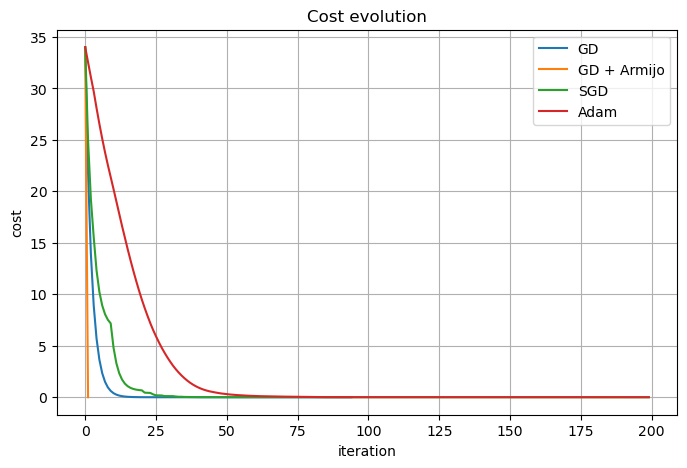

In [8]:
# Create a figure for the cost histories.
plt.figure(figsize=(8, 5))

# Plot the cost history for standard gradient descent.
plt.plot(costs_gd, label="GD")

# Plot the cost history for Armijo gradient descent.
plt.plot(costs_armijo, label="GD + Armijo")

# Plot the cost history for SGD.
plt.plot(costs_sgd, label="SGD")

# Plot the cost history for Adam.
plt.plot(costs_adam, label="Adam")

# Label the axes.
plt.xlabel("iteration")
plt.ylabel("cost")

# Add a title.
plt.title("Cost evolution")

# Add a legend.
plt.legend()

# Add a grid.
plt.grid(True)

# Show the figure.
plt.show()

## Comparison with Standard Libraries

We now compare with simple standard-library versions of:
- Gradient Descent,
- SGD,
- Adam.

To keep everything simple:
- we use `scipy.optimize.minimize` with the method `"GD"` if available in the local SciPy version, and otherwise we use `"BFGS"` as a deterministic reference,
- we use `torch.optim.SGD` for SGD,
- we use `torch.optim.Adam` for Adam.


In [9]:
# Import SciPy and PyTorch.
from scipy.optimize import minimize
import torch

In [10]:
# Define the objective for SciPy.
def f_scipy(theta):
    # Return the value of the cost function.
    return (theta[0] - 1)**2 + (theta[1] + 2)**2

# Define the gradient for SciPy.
def grad_scipy(theta):
    # Return the gradient as a NumPy array.
    return np.array([2*(theta[0] - 1), 2*(theta[1] + 2)])

# Call SciPy for a simple deterministic comparison.
result_det = minimize(f_scipy, x0=theta0, jac=grad_scipy, method="BFGS")

# Print the deterministic library result.
print("SciPy deterministic method")
print("final solution =", result_det.x)
print("iterations     =", result_det.nit)
print("final cost     =", result_det.fun)

SciPy deterministic method
final solution = [ 1. -2.]
iterations     = 3
final cost     = 3.3526588471893e-30


In [11]:
# Define the initial parameter tensor for PyTorch SGD.
theta_torch_sgd = torch.tensor([4.0, 3.0], dtype=torch.float32, requires_grad=True)

# Create a standard SGD optimizer.
optimizer_sgd = torch.optim.SGD([theta_torch_sgd], lr=0.1)

# Create an empty list to store the costs.
costs_torch_sgd = []

# Start the optimization loop.
for k in range(200):
    # Reset previous gradients.
    optimizer_sgd.zero_grad()
    # Define the cost function.
    loss = (theta_torch_sgd[0] - 1)**2 + (theta_torch_sgd[1] + 2)**2
    # Store the current cost.
    costs_torch_sgd.append(loss.item())
    # Compute the gradients.
    loss.backward()
    # Perform one optimizer step.
    optimizer_sgd.step()
    # Stop if the gradient norm is small.
    if theta_torch_sgd.grad.norm().item() < 1e-8:
        break

# Print the PyTorch SGD result.
print("PyTorch SGD")
print("final solution =", theta_torch_sgd.detach().numpy())
print("iterations     =", k + 1)
print("final cost     =", costs_torch_sgd[-1])

PyTorch SGD
final solution = [ 1.0000002 -1.9999998]
iterations     = 200
final cost     = 1.1368683772161603e-13


In [12]:
# Define the initial parameter tensor for PyTorch Adam.
theta_torch_adam = torch.tensor([4.0, 3.0], dtype=torch.float32, requires_grad=True)

# Create a standard Adam optimizer.
optimizer_torch_adam = torch.optim.Adam([theta_torch_adam], lr=0.15)

# Create an empty list to store the costs.
costs_torch_adam = []

# Start the optimization loop.
for k in range(200):
    # Reset previous gradients.
    optimizer_torch_adam.zero_grad()
    # Define the cost function.
    loss = (theta_torch_adam[0] - 1)**2 + (theta_torch_adam[1] + 2)**2
    # Store the current cost.
    costs_torch_adam.append(loss.item())
    # Compute the gradients.
    loss.backward()
    # Perform one optimizer step.
    optimizer_torch_adam.step()
    # Stop if the gradient norm is small.
    if theta_torch_adam.grad.norm().item() < 1e-8:
        break

# Print the PyTorch Adam result.
print("PyTorch Adam")
print("final solution =", theta_torch_adam.detach().numpy())
print("iterations     =", k + 1)
print("final cost     =", costs_torch_adam[-1])

PyTorch Adam
final solution = [ 1.0000852 -2.0001333]
iterations     = 200
final cost     = 2.2313599856715882e-08


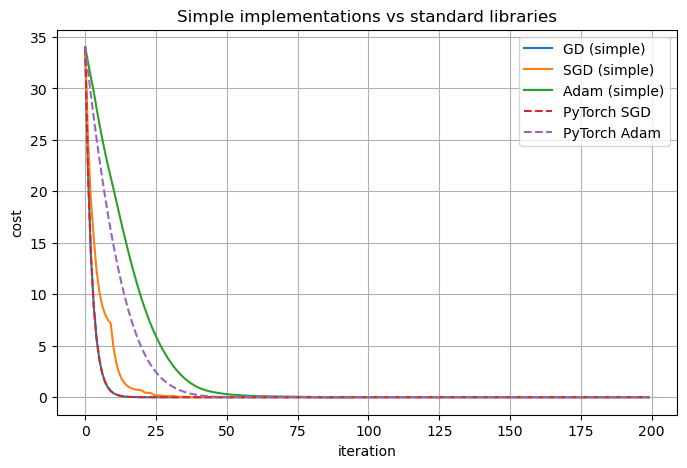

In [13]:
# Create a figure for the library comparison.
plt.figure(figsize=(8, 5))

# Plot the simple implementations.
plt.plot(costs_gd, label="GD (simple)")
plt.plot(costs_sgd, label="SGD (simple)")
plt.plot(costs_adam, label="Adam (simple)")

# Plot the library implementations.
plt.plot(costs_torch_sgd, "--", label="PyTorch SGD")
plt.plot(costs_torch_adam, "--", label="PyTorch Adam")

# Label the axes.
plt.xlabel("iteration")
plt.ylabel("cost")

# Add a title.
plt.title("Simple implementations vs standard libraries")

# Add a legend.
plt.legend()

# Add a grid.
plt.grid(True)

# Show the figure.
plt.show()